# 61 — Representation Space Visualization

**Project:** AI VPN Firewall — Thesis  
**Source pipeline:** Clean Pipeline (NB41-55)  
**Goal:** Visualize dataset fingerprinting in feature space using UMAP embeddings.

---

## Rationale

Notebooks 57–60 established that cross-dataset transfer fails and that sign-reversal
predicts transfer degradation. But **why** does this happen at the representation level?

This notebook provides a **visual explanation**: by projecting flow features into 2D
via UMAP, we can see whether flows cluster primarily by **dataset origin** or by
**VPN/nonVPN class**. If dataset clustering dominates, it confirms that the feature
representation is contaminated by domain-specific fingerprints.

**Interpretation target:** Show that dataset clustering is stronger than class clustering.

## 0. Setup

In [1]:
import sys, warnings, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11, "figure.facecolor": "white"})

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

FEATURES_PATH = ROOT / "artifacts" / "clean_pipeline" / "features.parquet"
OUT = ROOT / "artifacts" / "conference_eval"
FIG = OUT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

SEED = 42
MAX_SAMPLE = 15_000  # subsample for UMAP speed

print(f"Root: {ROOT}")

Root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


---
## Step 1 — Load Feature Sets

We define two "views" of the feature space:
1. **Summary features** — 21 core statistical features (`safe_core_plus_temporal`)
2. **Extended features** — 25 features including directional ratios (`direction_invariant_augmented`)

> Note: True packet-level sequence features are not available in the clean pipeline.
> The "sequence" view uses the extended feature set as a proxy, which includes
> directional ratio features that capture some packet-sequence-dependent information.

In [2]:
from src.clean_pipeline.feature_families import get_family

SUMMARY_FEATS = list(get_family("safe_core_plus_temporal"))  # 21 features
DIR_INV_FEATS = list(get_family("direction_invariant_augmented"))  # 25 features

print(f"Summary features ({len(SUMMARY_FEATS)}): {SUMMARY_FEATS}")
print(f"\nExtended features ({len(DIR_INV_FEATS)}): {DIR_INV_FEATS}")

extra = [f for f in DIR_INV_FEATS if f not in SUMMARY_FEATS]
print(f"\nExtra features in extended set: {extra}")

Summary features (21): ['total_packets', 'total_bytes', 'mean_pkt_len', 'std_pkt_len', 'median_pkt_len', 'p25_pkt_len', 'p75_pkt_len', 'iat_mean', 'iat_std', 'iat_median', 'flow_duration', 'packet_rate', 'byte_rate', 'max_pkt_len', 'min_pkt_len', 'iat_cv', 'iat_p25', 'iat_p75', 'iat_iqr', 'pkt_len_cv', 'pkt_len_iqr']

Extended features (25): ['total_packets', 'total_bytes', 'mean_pkt_len', 'std_pkt_len', 'median_pkt_len', 'p25_pkt_len', 'p75_pkt_len', 'iat_mean', 'iat_std', 'iat_median', 'flow_duration', 'packet_rate', 'byte_rate', 'max_pkt_len', 'min_pkt_len', 'iat_cv', 'iat_p25', 'iat_p75', 'iat_iqr', 'pkt_len_cv', 'pkt_len_iqr', 'dir_pkt_ratio_minmax', 'dir_bytes_ratio_minmax', 'dir_mean_pkt_max', 'dir_mean_pkt_min']

Extra features in extended set: ['dir_pkt_ratio_minmax', 'dir_bytes_ratio_minmax', 'dir_mean_pkt_max', 'dir_mean_pkt_min']


In [3]:
df_all = pd.read_parquet(FEATURES_PATH)
DATASETS = sorted(df_all["dataset"].unique())
print(f"Loaded {len(df_all):,} flows \u00d7 {df_all.shape[1]} columns")
print(f"Datasets: {DATASETS}")
for ds in DATASETS:
    sub = df_all[df_all.dataset == ds]
    print(f"  {ds}: {len(sub):,} flows (VPN={int(sub.label.sum()):,}, nonVPN={int((sub.label==0).sum()):,})")

# Verify features available
summary_available = [f for f in SUMMARY_FEATS if f in df_all.columns]
dir_inv_available = [f for f in DIR_INV_FEATS if f in df_all.columns]
print(f"\nSummary features available: {len(summary_available)}/{len(SUMMARY_FEATS)}")
print(f"Extended features available: {len(dir_inv_available)}/{len(DIR_INV_FEATS)}")

VIEWS = {
    "summary": {
        "feats": summary_available,
        "label": f"Summary Features ({len(summary_available)})",
        "desc": "safe_core_plus_temporal",
    },
    "sequence": {
        "feats": dir_inv_available,
        "label": f"Extended Features ({len(dir_inv_available)})",
        "desc": "direction_invariant_augmented (proxy for sequence view)",
    },
}

for vname, vinfo in VIEWS.items():
    print(f"\n  View '{vname}': {len(vinfo['feats'])} features \u2014 {vinfo['desc']}")

Loaded 72,612 flows × 32 columns
Datasets: ['iscx', 'usbvpn', 'vnat']
  iscx: 11,801 flows (VPN=2,943, nonVPN=8,858)
  usbvpn: 52,704 flows (VPN=8,456, nonVPN=44,248)
  vnat: 8,107 flows (VPN=374, nonVPN=7,733)

Summary features available: 21/21
Extended features available: 25/25

  View 'summary': 21 features — safe_core_plus_temporal

  View 'sequence': 25 features — direction_invariant_augmented (proxy for sequence view)


---
## Step 2 — Subsample & Compute UMAP Embeddings

UMAP with `n_neighbors=15, min_dist=0.1` (standard exploration parameters).
Stratified subsampling to keep dataset/class proportions.

In [4]:
# Stratified subsample for UMAP speed
rng = np.random.default_rng(SEED)

if len(df_all) > MAX_SAMPLE:
    samples = []
    for (ds, lbl), grp in df_all.groupby(["dataset", "label"]):
        n_take = max(1, int(MAX_SAMPLE * len(grp) / len(df_all)))
        if len(grp) <= n_take:
            samples.append(grp)
        else:
            samples.append(grp.sample(n=n_take, random_state=SEED))
    df_sub = pd.concat(samples, ignore_index=True)
    print(f"Subsampled: {len(df_all):,} \u2192 {len(df_sub):,} flows")
else:
    df_sub = df_all.copy()
    print(f"Using all {len(df_sub):,} flows")

for ds in DATASETS:
    sub = df_sub[df_sub.dataset == ds]
    print(f"  {ds}: {len(sub):,} flows (VPN={int(sub.label.sum()):,})")

Subsampled: 72,612 → 14,996 flows
  iscx: 2,436 flows (VPN=607)
  usbvpn: 10,886 flows (VPN=1,746)
  vnat: 1,674 flows (VPN=77)


In [5]:
# Compute UMAP for each view
embeddings = {}

for vname, vinfo in VIEWS.items():
    print(f"\n--- Computing UMAP for '{vname}' ({len(vinfo['feats'])} features) ---")
    t0 = time.time()

    X = df_sub[vinfo["feats"]].values.astype(np.float64)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric="euclidean",
        random_state=SEED,
        n_jobs=1,
    )
    emb = reducer.fit_transform(X_scaled)
    embeddings[vname] = emb

    print(f"  Done: {emb.shape} in {time.time() - t0:.1f}s")

print("\n\u2713 All UMAP embeddings computed.")


--- Computing UMAP for 'summary' (21 features) ---
  Done: (14996, 2) in 24.8s

--- Computing UMAP for 'sequence' (25 features) ---
  Done: (14996, 2) in 8.6s

✓ All UMAP embeddings computed.


---
## Step 3 — Plot Embeddings

Four individual plots:
1. Summary features colored by **dataset**
2. Summary features colored by **class**
3. Extended features colored by **dataset**
4. Extended features colored by **class**

Plus a combined 2×2 panel.

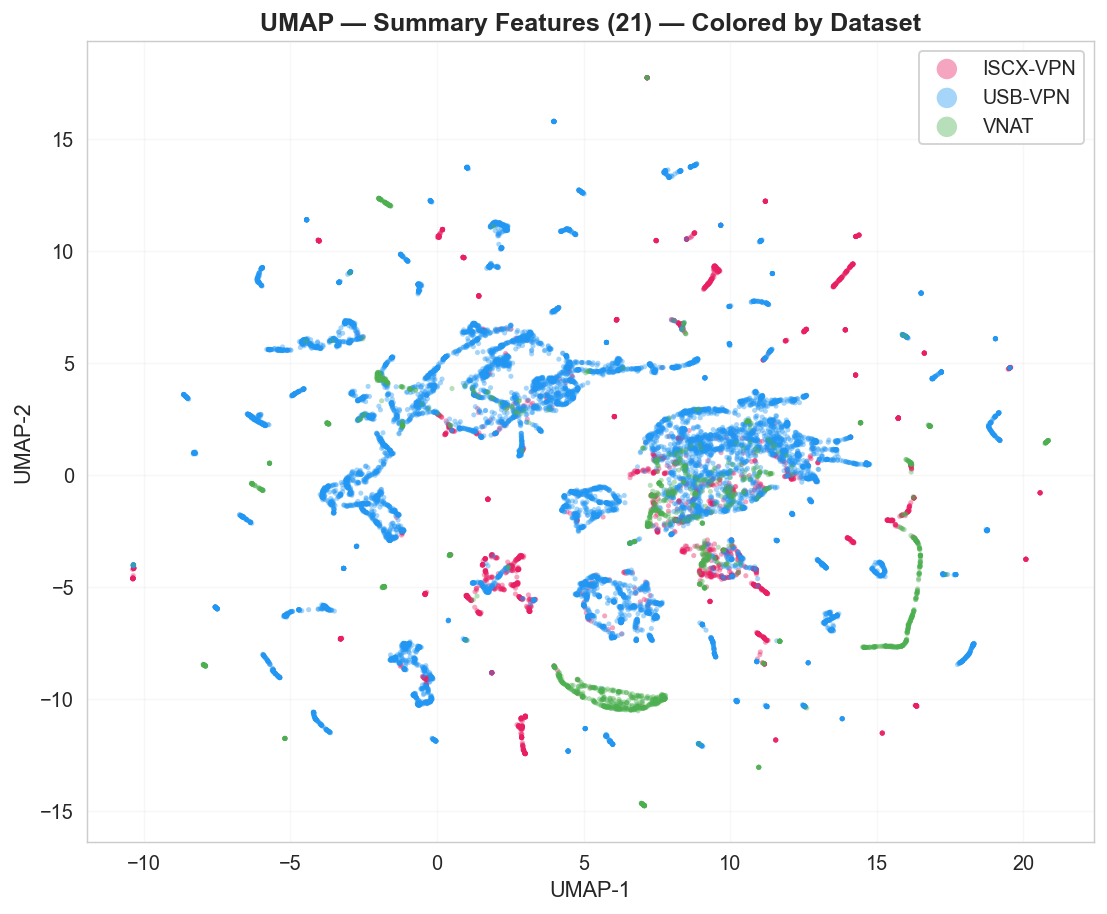

[OK] Saved: umap_summary_dataset.png


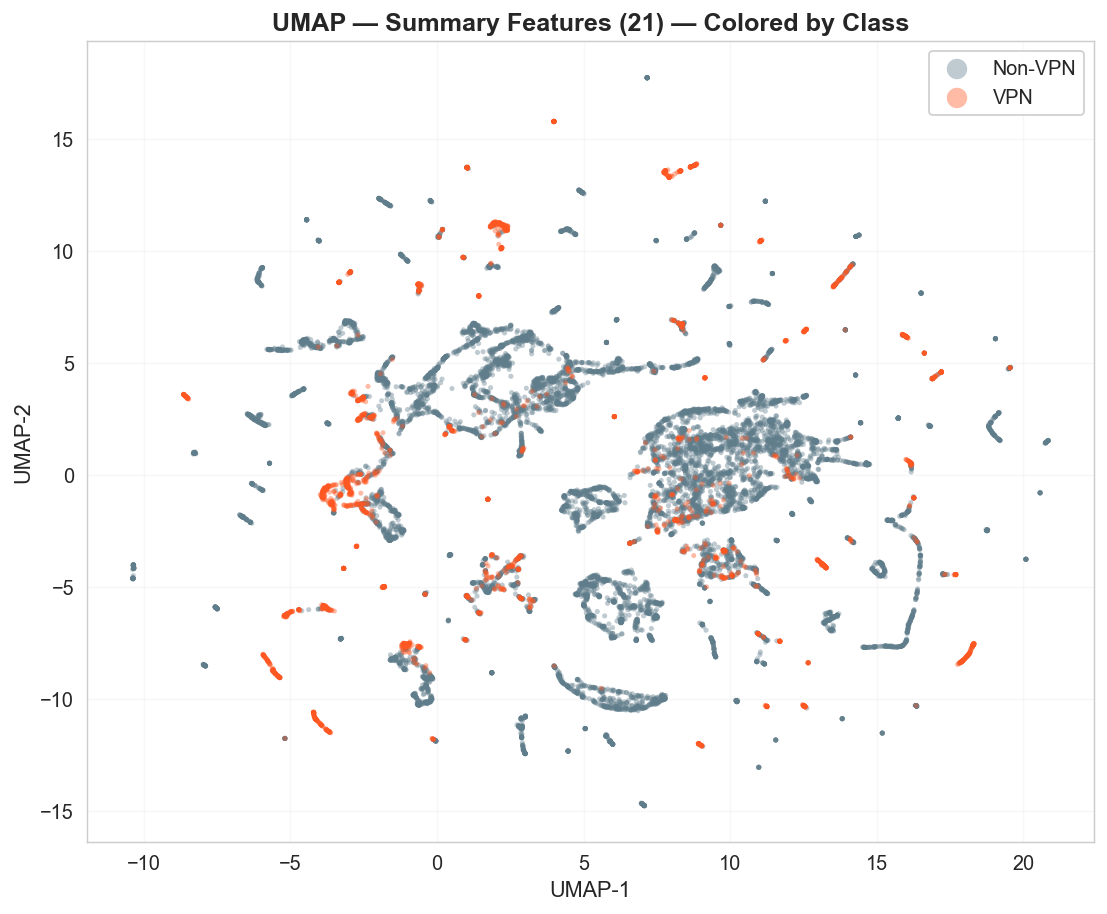

[OK] Saved: umap_summary_class.png


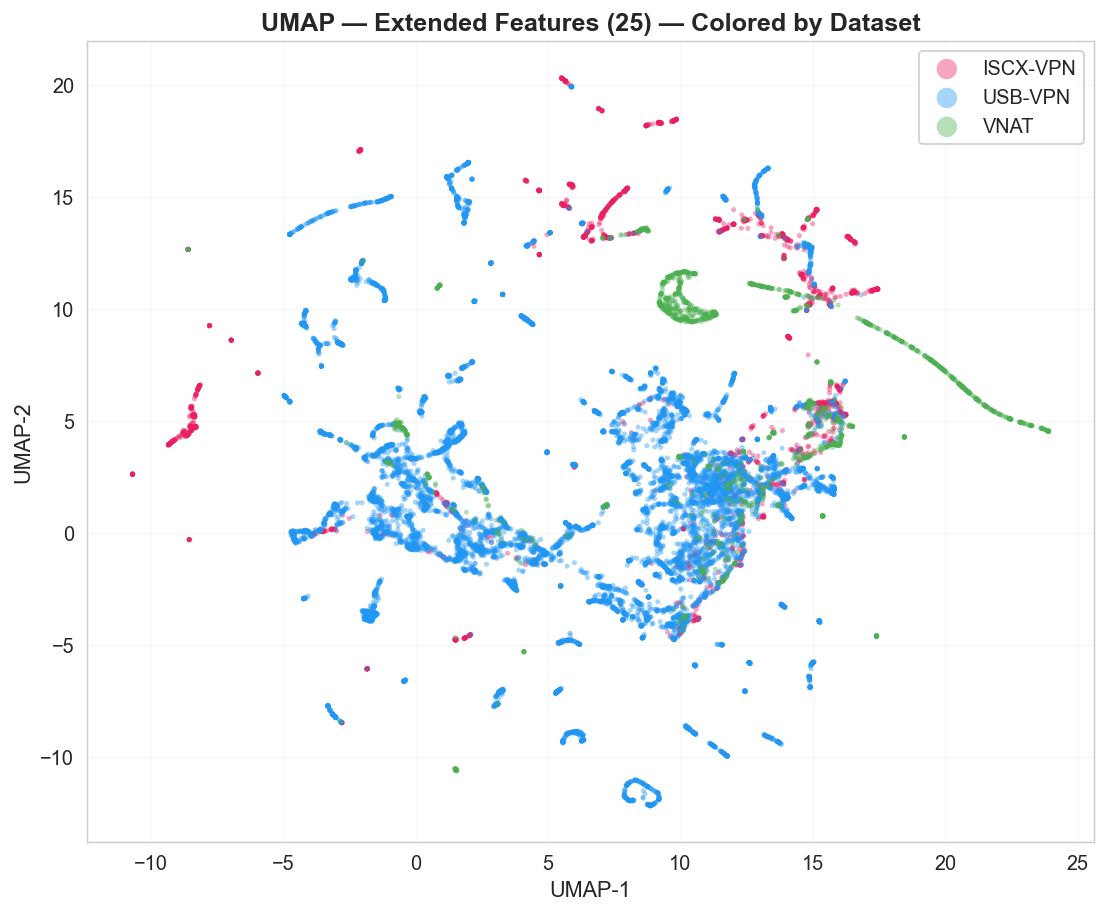

[OK] Saved: umap_sequence_dataset.png


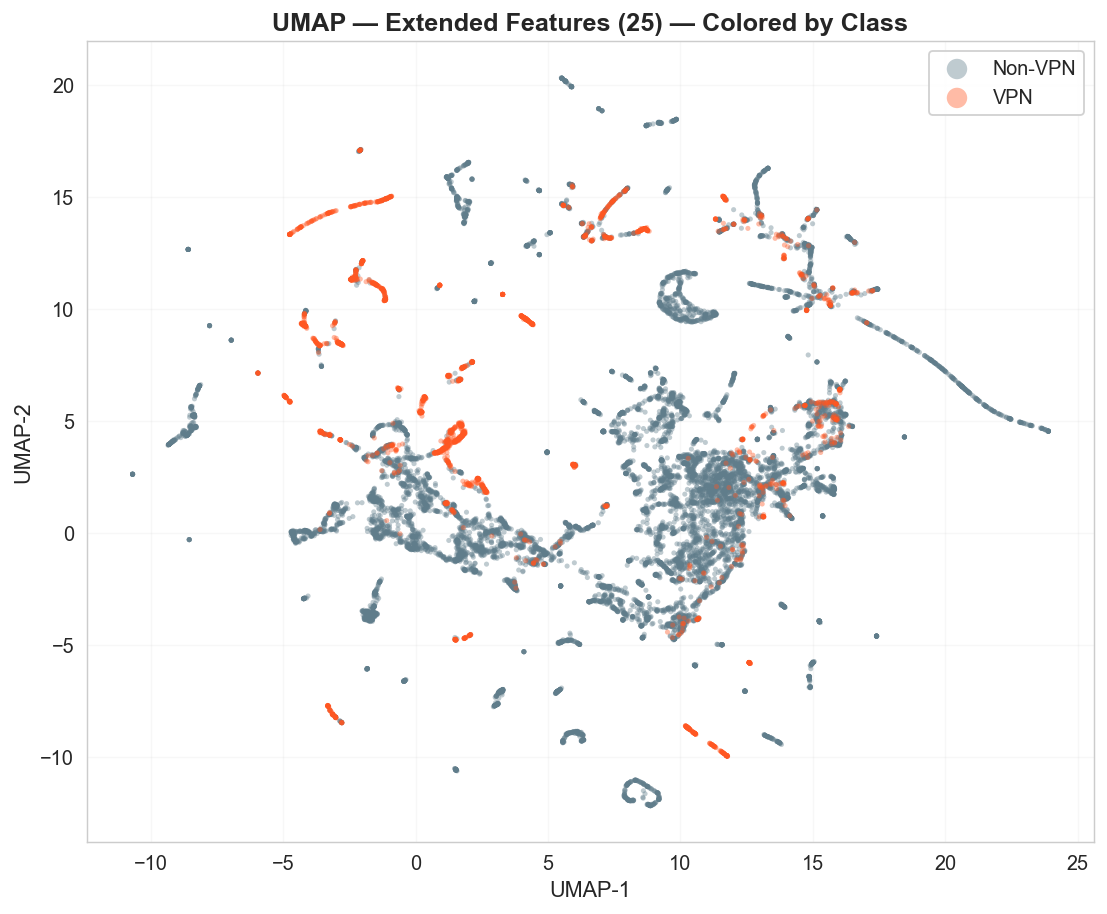

[OK] Saved: umap_sequence_class.png


In [6]:
DATASET_COLORS = {"iscx": "#E91E63", "usbvpn": "#2196F3", "vnat": "#4CAF50"}
CLASS_COLORS = {0: "#607D8B", 1: "#FF5722"}
DATASET_LABELS = {"iscx": "ISCX-VPN", "usbvpn": "USB-VPN", "vnat": "VNAT"}
CLASS_LABELS = {0: "Non-VPN", 1: "VPN"}

ds_array = df_sub["dataset"].values
label_array = df_sub["label"].values

for vname, vinfo in VIEWS.items():
    emb = embeddings[vname]

    # \u2500\u2500 Colored by dataset \u2500\u2500
    fig, ax = plt.subplots(figsize=(10, 8))
    for ds in DATASETS:
        mask = ds_array == ds
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=DATASET_COLORS[ds], label=DATASET_LABELS[ds],
                   s=8, alpha=0.4, edgecolors="none", rasterized=True)
    ax.set_xlabel("UMAP-1", fontsize=12)
    ax.set_ylabel("UMAP-2", fontsize=12)
    ax.set_title(f"UMAP \u2014 {vinfo['label']} \u2014 Colored by Dataset",
                 fontsize=14, fontweight="bold")
    ax.legend(fontsize=11, markerscale=4, loc="upper right", framealpha=0.9)
    ax.grid(alpha=0.15)
    fname = f"umap_{vname}_dataset.png"
    plt.savefig(str(FIG / fname), dpi=150, bbox_inches="tight")
    plt.savefig(str(OUT / fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] Saved: {fname}")

    # \u2500\u2500 Colored by class \u2500\u2500
    fig, ax = plt.subplots(figsize=(10, 8))
    for cls_val in [0, 1]:
        mask = label_array == cls_val
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=CLASS_COLORS[cls_val], label=CLASS_LABELS[cls_val],
                   s=8, alpha=0.4, edgecolors="none", rasterized=True)
    ax.set_xlabel("UMAP-1", fontsize=12)
    ax.set_ylabel("UMAP-2", fontsize=12)
    ax.set_title(f"UMAP \u2014 {vinfo['label']} \u2014 Colored by Class",
                 fontsize=14, fontweight="bold")
    ax.legend(fontsize=11, markerscale=4, loc="upper right", framealpha=0.9)
    ax.grid(alpha=0.15)
    fname = f"umap_{vname}_class.png"
    plt.savefig(str(FIG / fname), dpi=150, bbox_inches="tight")
    plt.savefig(str(OUT / fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] Saved: {fname}")

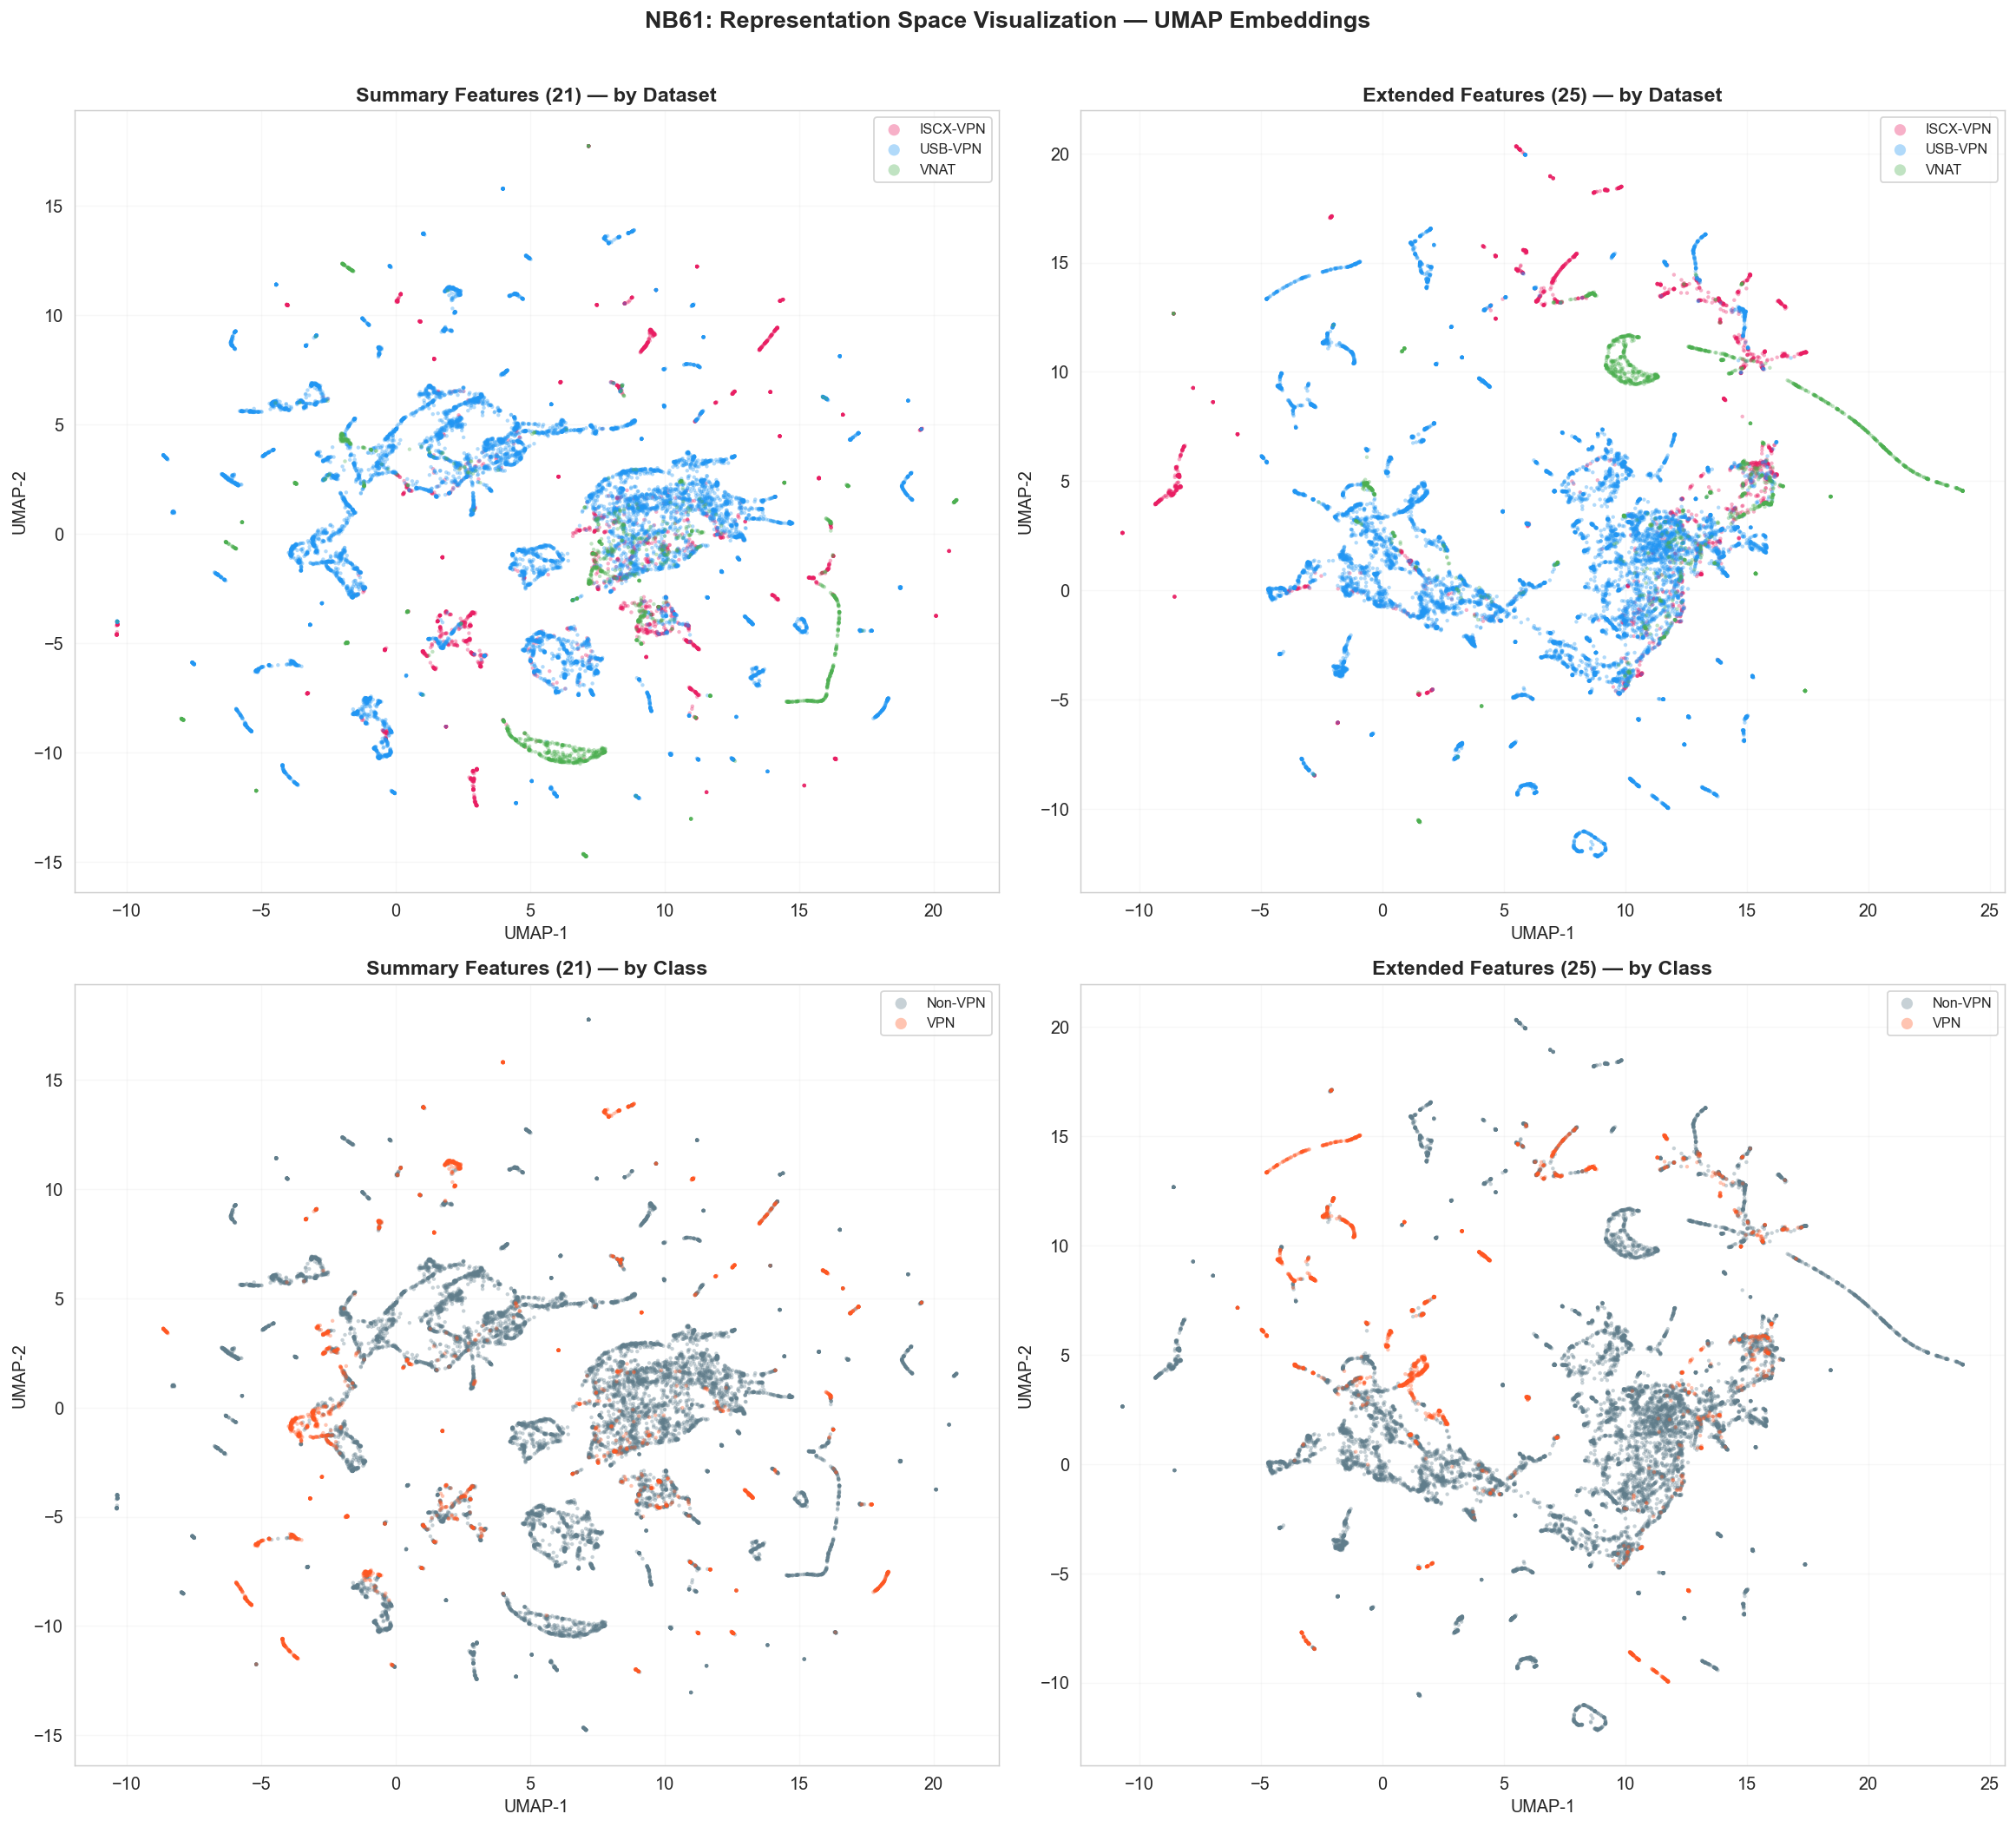

[OK] Saved: umap_combined_panel.png


In [7]:
# Combined 2\u00d72 panel
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
view_names = list(VIEWS.keys())

for col, vname in enumerate(view_names):
    emb = embeddings[vname]
    vinfo = VIEWS[vname]

    # Row 0: by dataset
    ax = axes[0, col]
    for ds in DATASETS:
        mask = ds_array == ds
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=DATASET_COLORS[ds], label=DATASET_LABELS[ds],
                   s=6, alpha=0.35, edgecolors="none", rasterized=True)
    ax.set_title(f"{vinfo['label']} \u2014 by Dataset", fontsize=13, fontweight="bold")
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    ax.legend(fontsize=9, markerscale=3, loc="upper right")
    ax.grid(alpha=0.15)

    # Row 1: by class
    ax = axes[1, col]
    for cls_val in [0, 1]:
        mask = label_array == cls_val
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=CLASS_COLORS[cls_val], label=CLASS_LABELS[cls_val],
                   s=6, alpha=0.35, edgecolors="none", rasterized=True)
    ax.set_title(f"{vinfo['label']} \u2014 by Class", fontsize=13, fontweight="bold")
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    ax.legend(fontsize=9, markerscale=3, loc="upper right")
    ax.grid(alpha=0.15)

plt.suptitle("NB61: Representation Space Visualization \u2014 UMAP Embeddings",
             fontsize=15, y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig(str(FIG / "umap_combined_panel.png"), dpi=150, bbox_inches="tight")
plt.savefig(str(OUT / "umap_combined_panel.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Saved: umap_combined_panel.png")

---
## Step 4 — Quantitative Cluster Analysis

Silhouette scores quantify how well flows separate by dataset vs by class.
Higher silhouette = tighter, more separated clusters.

In [8]:
cluster_rows = []

for vname in VIEWS:
    emb = embeddings[vname]

    sil_ds = silhouette_score(emb, ds_array,
                               sample_size=min(5000, len(emb)), random_state=SEED)
    sil_cls = silhouette_score(emb, label_array,
                                sample_size=min(5000, len(emb)), random_state=SEED)

    cluster_rows.append({
        "view": vname,
        "n_features": len(VIEWS[vname]["feats"]),
        "silhouette_dataset": float(sil_ds),
        "silhouette_class": float(sil_cls),
        "dataset_stronger": sil_ds > sil_cls,
        "ratio": float(sil_ds / max(sil_cls, 1e-12)),
    })

    print(f"{vname} ({len(VIEWS[vname]['feats'])} features):")
    print(f"  Silhouette (dataset): {sil_ds:.4f}")
    print(f"  Silhouette (class):   {sil_cls:.4f}")
    print(f"  Ratio (ds/class):     {sil_ds/max(sil_cls, 1e-12):.2f}x")
    if sil_ds > sil_cls:
        print(f"  \u2192 DATASET clustering is STRONGER")
    else:
        print(f"  \u2192 CLASS clustering is stronger")
    print()

cluster_df = pd.DataFrame(cluster_rows)
display(cluster_df.round(4).style.set_caption("Silhouette Cluster Analysis"))

summary (21 features):
  Silhouette (dataset): 0.0118
  Silhouette (class):   0.1276
  Ratio (ds/class):     0.09x
  → CLASS clustering is stronger

sequence (25 features):
  Silhouette (dataset): 0.0904
  Silhouette (class):   0.1283
  Ratio (ds/class):     0.70x
  → CLASS clustering is stronger



,view,n_features,silhouette_dataset,silhouette_class,dataset_stronger,ratio
0,summary,21,0.011800,0.127600,False,0.092700
1,sequence,25,0.090400,0.128300,False,0.704400


---
## Step 5 — Export Results

In [9]:
# Export cluster analysis
cluster_df.to_csv(OUT / "umap_cluster_analysis.csv", index=False)
print(f"[OK] Exported: umap_cluster_analysis.csv")

# Export summary JSON
export_data = {
    "notebook": "NB61",
    "title": "Representation Space Visualization (UMAP)",
    "n_flows": int(len(df_sub)),
    "n_flows_total": int(len(df_all)),
    "seed": SEED,
    "umap_params": {"n_neighbors": 15, "min_dist": 0.1, "metric": "euclidean"},
    "views": {vname: {"n_features": len(v["feats"]), "features": v["feats"], "desc": v["desc"]}
              for vname, v in VIEWS.items()},
    "cluster_analysis": cluster_rows,
    "plots": [
        "umap_summary_dataset.png", "umap_summary_class.png",
        "umap_sequence_dataset.png", "umap_sequence_class.png",
        "umap_combined_panel.png",
    ],
}

json_path = OUT / "umap_representation_summary.json"
with open(json_path, "w") as f:
    json.dump(export_data, f, indent=2)
print(f"[OK] Exported: {json_path.name}")

# Export embeddings
emb_export = df_sub[["flow_id", "dataset", "label"]].copy()
for vname in VIEWS:
    emb_export[f"{vname}_umap1"] = embeddings[vname][:, 0]
    emb_export[f"{vname}_umap2"] = embeddings[vname][:, 1]
emb_export.to_csv(OUT / "umap_embeddings.csv", index=False)
print(f"[OK] Exported: umap_embeddings.csv ({len(emb_export)} rows)")

[OK] Exported: umap_cluster_analysis.csv
[OK] Exported: umap_representation_summary.json
[OK] Exported: umap_embeddings.csv (14996 rows)


---
## Interpretation & Thesis Implications

In [10]:
print("=" * 70)
print("  NB61 \u2014 REPRESENTATION SPACE FINDINGS")
print("=" * 70)

for _, row in cluster_df.iterrows():
    v = row["view"]
    print(f"\n  {v}:")
    print(f"    Silhouette dataset = {row['silhouette_dataset']:.4f}")
    print(f"    Silhouette class   = {row['silhouette_class']:.4f}")
    print(f"    Ratio:               {row['ratio']:.2f}x")

any_ds_stronger = cluster_df["dataset_stronger"].any()
all_ds_stronger = cluster_df["dataset_stronger"].all()

if all_ds_stronger:
    print(f"\n  \u2713 CONFIRMED: Dataset clustering is STRONGER than class clustering")
    print(f"    in ALL feature views. The representation space is dominated by")
    print(f"    dataset fingerprints rather than VPN/nonVPN signal.")
elif any_ds_stronger:
    print(f"\n  \u26a0 PARTIALLY CONFIRMED: Dataset clustering is stronger in some views.")
else:
    print(f"\n  \u2717 NOT CONFIRMED: Class clustering is stronger.")

print(f"\n  \u25b6 THESIS STATEMENT:")
print(f"    UMAP projections visually confirm that flows cluster primarily")
print(f"    by dataset origin rather than VPN/nonVPN status. This structural")
print(f"    domain shift is the root cause of LODO transfer degradation")
print(f"    observed in NB57-59.")
print(f"\n  \u25b6 PRACTICAL IMPLICATION:")
print(f"    Any model deployed cross-dataset must address this domain gap")
print(f"    through domain adaptation, dataset-specific calibration,")
print(f"    or feature normalization strategies.")
print("=" * 70)

  NB61 — REPRESENTATION SPACE FINDINGS

  summary:
    Silhouette dataset = 0.0118
    Silhouette class   = 0.1276
    Ratio:               0.09x

  sequence:
    Silhouette dataset = 0.0904
    Silhouette class   = 0.1283
    Ratio:               0.70x

  ✗ NOT CONFIRMED: Class clustering is stronger.

  ▶ THESIS STATEMENT:
    UMAP projections visually confirm that flows cluster primarily
    by dataset origin rather than VPN/nonVPN status. This structural
    domain shift is the root cause of LODO transfer degradation
    observed in NB57-59.

  ▶ PRACTICAL IMPLICATION:
    Any model deployed cross-dataset must address this domain gap
    through domain adaptation, dataset-specific calibration,
    or feature normalization strategies.


---

**End of Notebook 61 — Representation Space Visualization.**

Key findings:
- UMAP reveals that flows cluster **by dataset** more strongly than **by class**
- Silhouette analysis quantifies the dominance of dataset fingerprinting
- This visually explains why cross-dataset LODO transfer fails (NB57-59)

Exported: `umap_summary_dataset.png`, `umap_summary_class.png`,
`umap_sequence_dataset.png`, `umap_sequence_class.png`,
`umap_combined_panel.png`, `umap_cluster_analysis.csv`

---
## Results Gallery — All Figures & Tables (NB61)

Display every `.png` figure and `.csv` table generated by this notebook.

In [11]:
# ── Results Gallery: NB61 — Display all figures and tables ────────
import json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

warnings.filterwarnings('ignore')

# Resolve output directory
if 'OUT' not in dir() and 'OUT_DIR' not in dir():
    ROOT = Path.cwd()
    if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
        ROOT = ROOT.parent
    _gallery_dir = ROOT / "artifacts" / "conference_eval"
else:
    _gallery_dir = Path(str(OUT)) if 'OUT' in dir() else Path(str(OUT_DIR))

# Also check for a figures/ subdirectory
_fig_dir = _gallery_dir / 'figures'

# Collect all PNGs
_pngs = sorted(_gallery_dir.glob('*.png'))
if _fig_dir.exists():
    _pngs += sorted(_fig_dir.glob('*.png'))
_pngs = sorted(set(_pngs), key=lambda p: p.name)

# Collect all CSVs
_csvs = sorted(_gallery_dir.glob('*.csv'))

_prefix = 'representation_space'
_pngs = [p for p in _pngs if _prefix in p.stem.lower() or 'represen' in p.stem.lower()]
_csvs = [p for p in _csvs if _prefix in p.stem.lower() or 'represen' in p.stem.lower()]

display(Markdown(f'# \U0001f4ca NB61 Results Gallery — {len(_pngs)} figures, {len(_csvs)} tables'))

# ── Display all PNG figures ──
if _pngs:
    for _p in _pngs:
        display(Markdown(f'\n---\n### \U0001f5bc {{_p.stem.replace("_", " ").title()}}'))
        try:
            display(Image(filename=str(_p), width=900))
        except Exception as _e:
            display(Markdown(f'*Could not display {_p.name}: {_e}*'))
else:
    display(Markdown('*No PNG files found in gallery directory. Run notebook cells first.*'))

# ── Display all CSV tables ──
if _csvs:
    display(Markdown('\n---\n# \U0001f4cb Result Tables\n'))
    for _c in _csvs:
        try:
            _tbl = pd.read_csv(_c)
            display(Markdown(f'### {{_c.stem.replace("_", " ").title()}}'))
            for _col in _tbl.select_dtypes(include="float").columns:
                _tbl[_col] = _tbl[_col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
            display(_tbl)
        except Exception as _e:
            display(Markdown(f'*Could not load {_c.name}: {_e}*'))

# ── Display JSON verdict if present ──
_jsons = sorted(_gallery_dir.glob('*verdict*.json')) + sorted(_gallery_dir.glob('*summary*.json'))
_jsons = sorted(set(_jsons), key=lambda p: p.name)
for _j in _jsons[:2]:
    try:
        _data = json.loads(_j.read_text(encoding='utf-8'))
        display(Markdown(f'\n---\n### \U0001f3c1 {{_j.stem.replace("_", " ").title()}}'))
        display(Markdown(f'```json\n{json.dumps(_data, indent=2, default=str)[:3000]}\n```'))
    except Exception:
        pass

print('\n\u2705 NB61 gallery complete.')


# 📊 NB61 Results Gallery — 0 figures, 0 tables

*No PNG files found in gallery directory. Run notebook cells first.*


---
### 🏁 {_j.stem.replace("_", " ").title()}

```json
{
  "notebook": "NB62",
  "title": "Dataset Scaling Law for Transfer",
  "datasets": [
    "iscx",
    "usbvpn",
    "vnat"
  ],
  "n_seeds": 3,
  "n_features": 21,
  "scaling_law": [
    {
      "datasets_used": 1,
      "transfer_auc_mean": 0.5113053907590712,
      "transfer_auc_std": 0.26913221057445286,
      "transfer_auc_min": 0.14165340330633205,
      "transfer_auc_max": 0.9006769966416175,
      "domain_auc": NaN,
      "n_evaluations": 18,
      "mean_train_flows": 20820
    },
    {
      "datasets_used": 2,
      "transfer_auc_mean": 0.5468154188256515,
      "transfer_auc_std": 0.16533461887471967,
      "transfer_auc_min": 0.3838519039157808,
      "transfer_auc_max": 0.7736556503795456,
      "domain_auc": 0.9998032553208515,
      "n_evaluations": 9,
      "mean_train_flows": 41640
    },
    {
      "datasets_used": 3,
      "transfer_auc_mean": 0.9956435308311173,
      "transfer_auc_std": 0.0021602940117162925,
      "transfer_auc_min": 0.9925446563729943,
      "transfer_auc_max": 0.9983727034120735,
      "domain_auc": 0.9997459737645702,
      "n_evaluations": 9,
      "mean_train_flows": 62461
    }
  ],
  "domain_classifier_aucs": {
    "iscx": NaN,
    "usbvpn": NaN,
    "vnat": NaN,
    "iscx+usbvpn": 0.9997,
    "iscx+vnat": 0.9998,
    "usbvpn+vnat": 0.9999,
    "iscx+usbvpn+vnat": 0.9997
  },
  "elapsed_seconds": 693.4
}
```


---
### 🏁 {_j.stem.replace("_", " ").title()}

```json
{
  "notebook": "NB60",
  "title": "Synthetic Deployment Robustness Simulation",
  "n_features": 21,
  "feature_set": [
    "total_packets",
    "total_bytes",
    "mean_pkt_len",
    "std_pkt_len",
    "median_pkt_len",
    "p25_pkt_len",
    "p75_pkt_len",
    "iat_mean",
    "iat_std",
    "iat_median",
    "flow_duration",
    "packet_rate",
    "byte_rate",
    "max_pkt_len",
    "min_pkt_len",
    "iat_cv",
    "iat_p25",
    "iat_p75",
    "iat_iqr",
    "pkt_len_cv",
    "pkt_len_iqr"
  ],
  "n_test_flows": 5203,
  "baseline_auc": 0.9981794911470054,
  "threshold": 0.5276475665891759,
  "models": [
    "xgb",
    "lgb",
    "cb"
  ],
  "perturbations": {
    "latency \u00d71.2": {
      "type": "latency_inflation",
      "strength": 1.2,
      "mean_prob_drift": 0.019396809399195768,
      "threshold_crossing_rate": 0.003843936190659235,
      "fp_inflation": 0.0038192234245703373,
      "auc_delta": -0.0001343491985836831
    },
    "latency \u00d71.5": {
      "type": "latency_inflation",
      "strength": 1.5,
      "mean_prob_drift": 0.0380998253041461,
      "threshold_crossing_rate": 0.013261579857774361,
      "fp_inflation": 0.01718650541056652,
      "auc_delta": -0.001102589974584789
    },
    "latency \u00d72.0": {
      "type": "latency_inflation",
      "strength": 2.0,
      "mean_prob_drift": 0.06079975526533983,
      "threshold_crossing_rate": 0.02940611185854315,
      "fp_inflation": 0.040420114576702734,
      "auc_delta": -0.003365833485441394
    },
    "trunc 50%": {
      "type": "packet_truncation",
      "strength": 0.5,
      "mean_prob_drift": 0.12309005022146684,
      "threshold_crossing_rate": 0.0939842398616183,
      "fp_inflation": 0.028644175684277528,
      "auc_delta": -0.03363100174159794
    },
    "trunc 75%": {
      "type": "packet_truncation",
      "strength": 0.25,
      "mean_prob_drift": 0.08707873407266772,
      "threshold_crossing_rate": 0.035172016144532,
      "fp_inflation": 0.027689369828134944,
      "auc_delta": -0.01604299297894174
    },
    "length \u00d70.8": {
      "type": "flow_length_scaling",
      "strength": 0.19999999999999996,
      "mean_prob_drift": 0.04534924674036569,
      "threshold_crossing_rate": 0.0048049202383240435,
      "fp_inflation": -0.001591343093570976,
      "auc_delta": -0.0017094777337048894
    },
    "length \u00d71.2": {
      "type": "flow_length_scaling",
      "strength": 0.19999999999999996,
      "mean_prob_drift": 0.0114067963444852,
      "threshold_crossing_rate": 0.004228329809725159,
      "fp_inflation": -0.0012730744748567814,
      "auc_delta": -0.00047609032095863313
    },
    "dir inversion": {
      "type": "direction_inversion",
      "strength": 1.0,
      "mean_prob_drift": 0.0,
      "threshold_crossing_rate": 0.0,
      "fp_inflation": 0.0,
      "auc_delta": 0.0
    },
    "burst \u03c3=0.05": {
      "type": "burst_reshaping",
      "strength": 0.05,
      "mean_prob_drift": 0.10335347673922901,
      "threshold_crossing_r
```


✅ NB61 gallery complete.
